In [129]:
!pip install -q transformers opencv-contrib-python scipy torch torchvision torchmetrics

In [130]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import CelebA
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub
from PIL import Image
import cv2
import csv
from datetime import datetime
import json

# Download dataset
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print("Downloading CelebA dataset...")
output_base = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Dataset downloaded to: {output_base}")

Dataset downloaded to: /kaggle/input/datasets/jessicali9530/celeba-dataset


In [131]:
!pip install -q opencv-contrib-python scipy torchmetrics --upgrade

In [132]:
import cv2
from scipy.ndimage import rotate
import numpy as np

class FacePreprocessor:
    """Face detection, extraction and alignment using OpenCV (simpler alternative to MediaPipe)"""
    def __init__(self, target_size=(128, 128)):
        self.target_size = target_size
        
        # Use OpenCV's pre-trained face detector (more reliable than MediaPipe 0.10.33)
        cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv2.CascadeClassifier(cascade_path)
        
    def detect_and_crop_face(self, image):
        """Detect and crop face region"""
        if isinstance(image, str):
            image = cv2.imread(image)
            if image is None:
                return None
        
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = self.face_cascade.detectMultiScale(
            gray, 
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        
        if len(faces) == 0:
            return None
        
        # Get largest face
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        
        # Add padding
        padding = int(0.1 * w)
        x = max(0, x - padding)
        y = max(0, y - padding)
        x2 = min(image.shape[1], x + w + 2*padding)
        y2 = min(image.shape[0], y + h + 2*padding)
        
        face = image[y:y2, x:x2]
        return face if face.size > 0 else None
    
    def align_face(self, image):
        """Simple face alignment by squaring the crop"""
        if isinstance(image, str):
            image = cv2.imread(image)
        if image is None:
            return None
        
        # Make square by centering the smaller dimension
        h, w = image.shape[:2]
        size = min(h, w)
        y_start = (h - size) // 2
        x_start = (w - size) // 2
        
        squared = image[y_start:y_start+size, x_start:x_start+size]
        return squared
    
    def preprocess(self, image_path, align=True):
        """Full preprocessing pipeline"""
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        face = self.detect_and_crop_face(img)
        if face is None:
            return None
        
        if align:
            face = self.align_face(face)
        
        # Resize to target size
        face = cv2.resize(face, self.target_size)
        # BGR to RGB
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        
        return face

In [133]:
print("✓ Face preprocessor initialized")

import csv

class CelebAFaceDataset(Dataset):
    """CelebA dataset with face preprocessing and attributes"""
    def __init__(self, img_dir, attr_file, processor, max_samples=None, use_cache=True):
        self.img_dir = img_dir
        self.processor = processor
        self.use_cache = use_cache
        self.cache = {}
        
        # Read attributes CSV file
        self.attributes = {}
        with open(attr_file, 'r', newline='') as csvfile:
            reader = csv.reader(csvfile)
            
            # Read header
            header = next(reader)
            self.attr_names = header[1:]  # Skip 'image_id'
            
            # Read data rows
            for row in reader:
                img_name = row[0]
                # Convert string attributes to int, then map -1 to 0, 1 to 1
                attrs = [(int(attr) + 1) // 2 for attr in row[1:]]
                self.attributes[img_name] = np.array(attrs, dtype=np.float32)
        
        self.image_names = list(self.attributes.keys())
        if max_samples:
            self.image_names = self.image_names[:max_samples]
        
        print(f"Dataset size: {len(self.image_names)} images")
        print(f"Attributes: {self.attr_names[:10]}...")
        
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        # Try cache first
        if self.use_cache and img_name in self.cache:
            face_image = self.cache[img_name]
        else:
            img_path = os.path.join(self.img_dir, img_name)
            face_image = self.processor.preprocess(img_path, align=True)
            
            if face_image is None:
                # Return a placeholder
                face_image = np.zeros((128, 128, 3), dtype=np.uint8)
            
            if self.use_cache:
                self.cache[img_name] = face_image
        
        # Convert to tensor and normalize to [-1, 1]
        face_tensor = torch.from_numpy(face_image).permute(2, 0, 1).float() / 127.5 - 1.0
        attrs = torch.FloatTensor(self.attributes[img_name])
        
        return face_tensor, attrs, img_name

✓ Face preprocessor initialized


In [134]:
class WGANGenerator(nn.Module):
    """WGAN Generator - deeper architecture for 128x128 images"""
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)

        self.deconv1 = nn.ConvTranspose2d(512, 256, 4, 2, 1)  # 8 -> 16
        self.deconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)  # 16 -> 32
        self.deconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)   # 32 -> 64
        self.deconv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)    # 64 -> 128
        self.conv_out = nn.Conv2d(32, 3, 3, 1, 1)              # 128 -> 128 (no upsample)

        self.bn1 = nn.InstanceNorm2d(256, affine=True)
        self.bn2 = nn.InstanceNorm2d(128, affine=True)
        self.bn3 = nn.InstanceNorm2d(64, affine=True)
        self.bn4 = nn.InstanceNorm2d(32, affine=True)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 8, 8)
        x = self.relu(self.bn1(self.deconv1(x)))
        x = self.relu(self.bn2(self.deconv2(x)))
        x = self.relu(self.bn3(self.deconv3(x)))
        x = self.relu(self.bn4(self.deconv4(x)))
        x = self.tanh(self.conv_out(x))
        return x

class WGANDiscriminatorV2(nn.Module):
    """WGAN Discriminator (Critic) with spectral normalization"""
    def __init__(self):
        super().__init__()

        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(3, 64, 4, 2, 1))    # 128 -> 64
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1))  # 64 -> 32
        self.conv3 = nn.utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)) # 32 -> 16
        self.conv4 = nn.utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1)) # 16 -> 8
        self.conv5 = nn.utils.spectral_norm(nn.Conv2d(512, 512, 4, 2, 1)) # 8 -> 4

        self.fc = nn.Linear(512 * 4 * 4, 1)

        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.leaky_relu(self.conv1(x))
        x = self.leaky_relu(self.conv2(x))
        x = self.leaky_relu(self.conv3(x))
        x = self.leaky_relu(self.conv4(x))
        x = self.leaky_relu(self.conv5(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Alias for compatibility
WGANDiscriminator = WGANDiscriminatorV2

def gradient_penalty(critic, real_data, fake_data, device, lambda_gp=10):
    """Gradient Penalty for WGAN-GP"""
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)

    interpolates = alpha * real_data + (1 - alpha) * fake_data
    interpolates.requires_grad_(True)

    critic_interpolates = critic(interpolates)

    grad_outputs = torch.ones(critic_interpolates.size(), device=device, requires_grad=True)
    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp

    return gradient_penalty

def gradient_penalty_conditional(critic, real_data, fake_data, attrs, device, lambda_gp=10):
    """Gradient Penalty for conditional WGAN-GP"""
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)

    interpolates = alpha * real_data + (1 - alpha) * fake_data
    interpolates.requires_grad_(True)

    critic_interpolates = critic(interpolates, attrs)

    grad_outputs = torch.ones(critic_interpolates.size(), device=device, requires_grad=True)
    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp_val = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp

    return gp_val


# Self-check: verify discriminator architecture
_disc_test = WGANDiscriminator()
_dummy_input = torch.randn(1, 3, 128, 128)
_dummy_output = _disc_test(_dummy_input)
_expected = 512 * 4 * 4
_actual_fc_in = _disc_test.fc.in_features
assert _actual_fc_in == _expected, f"Discriminator FC expects {_expected} features but got {_actual_fc_in}. The old class is still loaded in memory!"
del _disc_test, _dummy_input, _dummy_output
print(f"  Discriminator self-check passed (FC in_features={_actual_fc_in})")

  Discriminator self-check passed (FC in_features=8192)


In [135]:

class ConditionalWGANGenerator(nn.Module):
    """Conditional WGAN Generator - deeper architecture"""
    def __init__(self, latent_dim=128, num_attrs=40):
        super().__init__()
        self.latent_dim = latent_dim

        # Attribute embedding
        self.attr_embedding = nn.Sequential(
            nn.Linear(num_attrs, 128),
            nn.ReLU(),
            nn.Linear(128, 256)
        )

        self.fc = nn.Linear(latent_dim + 256, 512 * 8 * 8)

        self.deconv1 = nn.ConvTranspose2d(512, 256, 4, 2, 1)  # 8 -> 16
        self.deconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)  # 16 -> 32
        self.deconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)   # 32 -> 64
        self.deconv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)    # 64 -> 128
        self.conv_out = nn.Conv2d(32, 3, 3, 1, 1)              # 128 -> 128 (no upsample)

        self.bn1 = nn.InstanceNorm2d(256, affine=True)
        self.bn2 = nn.InstanceNorm2d(128, affine=True)
        self.bn3 = nn.InstanceNorm2d(64, affine=True)
        self.bn4 = nn.InstanceNorm2d(32, affine=True)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, z, attrs):
        attr_emb = self.attr_embedding(attrs)
        x = torch.cat([z, attr_emb], dim=1)
        x = self.fc(x)
        x = x.view(-1, 512, 8, 8)
        x = self.relu(self.bn1(self.deconv1(x)))
        x = self.relu(self.bn2(self.deconv2(x)))
        x = self.relu(self.bn3(self.deconv3(x)))
        x = self.relu(self.bn4(self.deconv4(x)))
        x = self.tanh(self.conv_out(x))
        return x

class ConditionalWGANDiscriminator(nn.Module):
    """Conditional WGAN Discriminator (Critic) with spectral normalization"""
    def __init__(self, num_attrs=40):
        super().__init__()

        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(3, 64, 4, 2, 1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1))
        self.conv3 = nn.utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1))
        self.conv4 = nn.utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1))
        self.conv5 = nn.utils.spectral_norm(nn.Conv2d(512, 512, 4, 2, 1))

        # Attribute embedding
        self.attr_embedding = nn.Sequential(
            nn.Linear(num_attrs, 128),
            nn.ReLU(),
            nn.Linear(128, 256)
        )

        self.fc = nn.Linear(512 * 4 * 4 + 256, 1)

        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x, attrs):
        x = self.leaky_relu(self.conv1(x))
        x = self.leaky_relu(self.conv2(x))
        x = self.leaky_relu(self.conv3(x))
        x = self.leaky_relu(self.conv4(x))
        x = self.leaky_relu(self.conv5(x))
        x = x.view(x.size(0), -1)

        attr_emb = self.attr_embedding(attrs)
        x = torch.cat([x, attr_emb], dim=1)

        x = self.fc(x)
        return x

In [136]:
from torchvision.models import inception_v3
from scipy import linalg

class InceptionFeatureExtractor:
    """Extract features from Inception network for FID/IS calculation"""
    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu', batch_size=32, use_amp=True):
        self.device = device
        self.batch_size = batch_size
        self.use_amp = use_amp and device.startswith('cuda')
        self.inception = inception_v3(pretrained=True, transform_input=False).to(device)
        self.inception.fc = nn.Identity()
        self.inception.eval()

        # Enable autocast for mixed precision if using CUDA
        if self.use_amp:
            self.scaler = torch.cuda.amp.GradScaler()

    def extract_features(self, images):
        """Extract features from batch of images (0-1 range) in smaller batches to avoid OOM"""
        all_features = []

        with torch.no_grad():
            # Process in batches to avoid OOM
            for i in range(0, len(images), self.batch_size):
                batch = images[i:i+self.batch_size].to(self.device)

                # Resize to 299x299 for Inception
                if batch.shape[2] != 299:
                    batch = nn.functional.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)

                # Normalize to ImageNet stats
                mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(self.device)
                std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(self.device)
                batch_normalized = (batch - mean) / std

                # Use mixed precision if enabled
                if self.use_amp:
                    with torch.cuda.amp.autocast():
                        features = self.inception(batch_normalized)
                else:
                    features = self.inception(batch_normalized)

                all_features.append(features.cpu())

                # Clear cache to free memory
                if self.device.startswith('cuda'):
                    torch.cuda.empty_cache()

        return torch.cat(all_features, dim=0).numpy()

def calculate_fid(real_features, fake_features):
    """Calculate Fréchet Inception Distance"""
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    
    cov_real = np.cov(real_features.T)
    cov_fake = np.cov(fake_features.T)
    
    # FID score
    diff = mu_real - mu_fake
    cov_sqrt = linalg.sqrtm(cov_real @ cov_fake)
    
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = np.real(cov_sqrt)
    
    fid = np.sum(diff**2) + np.trace(cov_real) + np.trace(cov_fake) - 2*np.trace(cov_sqrt)
    
    return fid

def calculate_is(fake_features, num_splits=10):
    """Calculate Inception Score"""
    N = fake_features.shape[0]
    
    scores = []
    for i in range(num_splits):
        part = fake_features[i * (N // num_splits):(i + 1) * (N // num_splits)]
        
        # Get predictions from Inception (for classification)
        # For IS, we use ImageNet probabilities
        p_y = np.mean(part, axis=0)  # Average predictions
        entropy = -np.sum(p_y * np.log(p_y + 1e-16))
        
        scores.append(entropy)
    
    # Average and std of KL divergence
    is_score = np.exp(np.mean(scores))
    is_std = np.std(scores)
    
    return is_score, is_std

In [137]:
# Configuration
# Check for multiple GPUs
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Found {num_gpus} GPU(s)")
    # Use GPU 0 for training, GPU 1 for metrics if available
    train_device = 'cuda:0'
    metrics_device = 'cuda:1' if num_gpus > 1 else 'cuda:0'
else:
    train_device = 'cpu'
    metrics_device = 'cpu'

config = {
    'device': train_device,
    'metrics_device': metrics_device,
    'batch_size': 16,
    'learning_rate_wgan': 1e-4,
    'latent_dim': 128,
    'num_attrs': 40,
    'max_samples': 5000,  # Use subset for faster training
    'num_epochs': 20,
    'metrics_batch_size': 8,  # Smaller batch for Inception network
    'max_fid_samples': 1000,  # Limit samples for FID calculation
}

print(f"Device: {config['device']}")
print(f"Using {config['max_samples']} samples for training")

# Create data directory
data_dir = os.path.join('lab4', 'data_prepared')
os.makedirs(data_dir, exist_ok=True)

# Initialize face preprocessor
print("\\nInitializing face preprocessor...")
processor = FacePreprocessor(target_size=(128, 128))

# Check if we have CelebA attributes file
celeba_img_dir = os.path.join(output_base, 'img_align_celeba/img_align_celeba')
celeba_attr_file = os.path.join(output_base, 'list_attr_celeba.csv')

if not os.path.exists(celeba_attr_file):
    print("Warning: CelebA attributes file not found!")
    print(f"Looking for: {celeba_attr_file}")
else:
    print(f"Found attributes file: {celeba_attr_file}")

if os.path.exists(celeba_attr_file) and os.path.exists(celeba_img_dir):
    try:
        dataset = CelebAFaceDataset(
            celeba_img_dir, 
            celeba_attr_file,
            processor,
            max_samples=config['max_samples'],
            use_cache=False  # Set to True to cache preprocessed images
        )
        
        # Split into train/val
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    except Exception as e:
        print(f"Error creating dataset: {e}")
        print("Using placeholder dataset for testing...")
        dataset = None
else:
    print("Dataset files not found. Please ensure CelebA is properly extracted.")

Found 2 GPU(s)
Device: cuda:0
Using 5000 samples for training
\nInitializing face preprocessor...
Found attributes file: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv
Dataset size: 5000 images
Attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair']...


In [138]:
def weights_init(m):
    """Initialize weights for GAN training"""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1 or classname.find('InstanceNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

In [139]:
def train_wgan(generator, discriminator, train_loader, config, num_epochs=20, critic_iterations=5):
    """Train unconditional WGAN-GP"""
    device = config['device']
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    # Apply weight initialization
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    # WGAN-GP paper recommends betas=(0.0, 0.9)
    opt_g = optim.Adam(generator.parameters(), lr=config['learning_rate_wgan'], betas=(0.0, 0.9))
    opt_d = optim.Adam(discriminator.parameters(), lr=config['learning_rate_wgan'], betas=(0.0, 0.9))
    
    history = {'gen_loss': [], 'disc_loss': [], 'gp': []}
    
    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        gen_loss_epoch = 0
        disc_loss_epoch = 0
        gp_epoch = 0
        
        for batch_idx, (real_images, _, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [WGAN]')):
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            # Train Discriminator
            for _ in range(critic_iterations):
                z = torch.randn(batch_size, config['latent_dim'], device=device)
                fake_images = generator(z).detach()
                
                # Critic scores
                real_scores = discriminator(real_images)
                fake_scores = discriminator(fake_images)
                
                # Gradient penalty
                gp = gradient_penalty(discriminator, real_images, fake_images, device, lambda_gp=10)
                
                # WGAN loss
                disc_loss = fake_scores.mean() - real_scores.mean() + gp
                
                opt_d.zero_grad()
                disc_loss.backward()
                opt_d.step()
                
                disc_loss_epoch += disc_loss.item()
                gp_epoch += gp.item()
            
            # Train Generator
            z = torch.randn(batch_size, config['latent_dim'], device=device)
            fake_images = generator(z)
            fake_scores = discriminator(fake_images)
            gen_loss = -fake_scores.mean()

            opt_g.zero_grad()
            gen_loss.backward()
            opt_g.step()

            gen_loss_epoch += gen_loss.item()

            # Clear cache to free memory
            if device.startswith('cuda'):
                torch.cuda.empty_cache()
        
        gen_loss_epoch /= len(train_loader)
        disc_loss_epoch /= (len(train_loader) * critic_iterations)
        gp_epoch /= (len(train_loader) * critic_iterations)
        
        history['gen_loss'].append(gen_loss_epoch)
        history['disc_loss'].append(disc_loss_epoch)
        history['gp'].append(gp_epoch)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Gen Loss: {gen_loss_epoch:.4f} | "
              f"Disc Loss: {disc_loss_epoch:.4f} | GP: {gp_epoch:.4f}")
    
    return generator, discriminator, history

# Train unconditional WGAN-GP
if dataset is not None:
    print("\\nTraining Unconditional WGAN-GP...")
    wgan_gen = WGANGenerator(latent_dim=config['latent_dim'])
    wgan_disc = WGANDiscriminator()

    # Diagnostic: verify discriminator architecture before training
    _disc_diag = wgan_disc
    print(f"  Discriminator conv layers: {len([m for m in _disc_diag.modules() if isinstance(m, nn.Conv2d)])}")
    print(f"  Discriminator FC in_features: {_disc_diag.fc.in_features}")
    _test_in = torch.randn(1, 3, 128, 128)
    _test_out = _disc_diag(_test_in)
    print(f"  Test forward pass: 1x3x128x128 -> {_test_out.shape}")

    wgan_gen, wgan_disc, wgan_history = train_wgan(
        wgan_gen, wgan_disc, train_loader, config,
        num_epochs=config['num_epochs']//2, critic_iterations=5
    )

    # Save models
    torch.save(wgan_gen.state_dict(), os.path.join('lab4', 'wgan_gen_unconditional.pth'))
    torch.save(wgan_disc.state_dict(), os.path.join('lab4', 'wgan_disc_unconditional.pth'))
else:
    print("Skipping WGAN training - no dataset available")

\nTraining Unconditional WGAN-GP...
  Discriminator conv layers: 5
  Discriminator FC in_features: 8192
  Test forward pass: 1x3x128x128 -> torch.Size([1, 1])


Epoch 1/10 [WGAN]: 100%|██████████| 250/250 [03:43<00:00,  1.12it/s]


Epoch 1/10 | Gen Loss: -188.1027 | Disc Loss: -81.7888 | GP: 33.9043


Epoch 2/10 [WGAN]: 100%|██████████| 250/250 [03:40<00:00,  1.13it/s]


Epoch 2/10 | Gen Loss: -350.7291 | Disc Loss: -61.1985 | GP: 25.5979


...

Epoch 8/10 | Gen Loss: -450.0036 | Disc Loss: -44.2934 | GP: 20.1313


Epoch 9/10 [WGAN]: 100%|██████████| 250/250 [03:41<00:00,  1.13it/s]


Epoch 9/10 | Gen Loss: -472.0046 | Disc Loss: -40.5469 | GP: 18.2543


Epoch 10/10 [WGAN]: 100%|██████████| 250/250 [03:41<00:00,  1.13it/s]

Epoch 10/10 | Gen Loss: -532.6565 | Disc Loss: -36.2384 | GP: 15.4643


In [140]:
def train_conditional_wgan(gen, disc, train_loader, config, num_epochs=20, critic_iterations=5):
    """Train conditional WGAN-GP with gradient penalty"""
    device = config['device']
    gen = gen.to(device)
    disc = disc.to(device)

    # Apply weight initialization
    gen.apply(weights_init)
    disc.apply(weights_init)

    opt_g = optim.Adam(gen.parameters(), lr=config['learning_rate_wgan'], betas=(0.0, 0.9))
    opt_d = optim.Adam(disc.parameters(), lr=config['learning_rate_wgan'], betas=(0.0, 0.9))
    
    history = {'gen_loss': [], 'disc_loss': [], 'gp': []}

    for epoch in range(num_epochs):
        gen.train()
        disc.train()
        gen_loss_epoch = 0
        disc_loss_epoch = 0
        gp_epoch = 0
        
        for batch_idx, (real_images, attrs, _) in enumerate(tqdm(train_loader, desc=f'c-WGAN Epoch {epoch+1}/{num_epochs}')):
            real_images = real_images.to(device)
            attrs = attrs.to(device)
            batch_size = real_images.size(0)

            # Train Discriminator
            for _ in range(critic_iterations):
                z = torch.randn(batch_size, config['latent_dim'], device=device)
                fake_images = gen(z, attrs).detach()

                real_scores = disc(real_images, attrs)
                fake_scores = disc(fake_images, attrs)

                # Gradient penalty with matching attributes
                gp = gradient_penalty_conditional(disc, real_images, fake_images, attrs, device, lambda_gp=10)
                disc_loss = fake_scores.mean() - real_scores.mean() + gp

                opt_d.zero_grad()
                disc_loss.backward()
                opt_d.step()

                disc_loss_epoch += disc_loss.item()
                gp_epoch += gp.item()

            # Train Generator
            z = torch.randn(batch_size, config['latent_dim'], device=device)
            fake_images = gen(z, attrs)
            fake_scores = disc(fake_images, attrs)
            gen_loss = -fake_scores.mean()

            opt_g.zero_grad()
            gen_loss.backward()
            opt_g.step()

            gen_loss_epoch += gen_loss.item()

            # Clear cache to free memory
            if device.startswith('cuda'):
                torch.cuda.empty_cache()

        gen_loss_epoch /= len(train_loader)
        disc_loss_epoch /= (len(train_loader) * critic_iterations)
        gp_epoch /= (len(train_loader) * critic_iterations)

        history['gen_loss'].append(gen_loss_epoch)
        history['disc_loss'].append(disc_loss_epoch)
        history['gp'].append(gp_epoch)

        print(f"Epoch {epoch+1}/{num_epochs} | Gen Loss: {gen_loss_epoch:.4f} | Disc Loss: {disc_loss_epoch:.4f} | GP: {gp_epoch:.4f}")
    
    return gen, disc, history

# Train conditional models
if dataset is not None:
    print("\\nTraining Conditional WGAN-GP...")
    cwgan_gen = ConditionalWGANGenerator(latent_dim=config['latent_dim'], num_attrs=config['num_attrs'])
    cwgan_disc = ConditionalWGANDiscriminator(num_attrs=config['num_attrs'])

    cwgan_gen, cwgan_disc, cwgan_history = train_conditional_wgan(
        cwgan_gen, cwgan_disc, train_loader, config, 
        num_epochs=config['num_epochs']//2, critic_iterations=5
    )

    torch.save(cwgan_gen.state_dict(), os.path.join('lab4', 'cwgan_gen_conditional.pth'))
    torch.save(cwgan_disc.state_dict(), os.path.join('lab4', 'cwgan_disc_conditional.pth'))
else:
    print("Skipping conditional training - no dataset available")

\nTraining Conditional WGAN-GP...


c-WGAN Epoch 1/10: 100%|██████████| 250/250 [03:40<00:00,  1.13it/s]


Epoch 1/10 | Gen Loss: -147.4991 | Disc Loss: -70.1729 | GP: 30.0952


c-WGAN Epoch 2/10: 100%|██████████| 250/250 [03:42<00:00,  1.12it/s]


Epoch 2/10 | Gen Loss: -359.1625 | Disc Loss: -40.2917 | GP: 15.1985


...

Epoch 8/10 | Gen Loss: -479.3640 | Disc Loss: -43.3089 | GP: 19.8921


c-WGAN Epoch 9/10: 100%|██████████| 250/250 [03:55<00:00,  1.06it/s]


Epoch 9/10 | Gen Loss: -525.3527 | Disc Loss: -39.6215 | GP: 17.3681


c-WGAN Epoch 10/10: 100%|██████████| 250/250 [03:55<00:00,  1.06it/s]


Epoch 10/10 | Gen Loss: -547.3541 | Disc Loss: -38.7550 | GP: 16.8083


In [141]:
def plot_training_curves(histories, title="Training Curves"):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # WGAN losses
    if len(histories['wgan']['gen_loss']) > 0:
        axes[0].plot(histories['wgan']['gen_loss'], label='Generator')
        axes[0].plot(histories['wgan']['disc_loss'], label='Discriminator')
        axes[0].set_title('Unconditional WGAN - Losses')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)

    # WGAN GP
    if len(histories['wgan']['gp']) > 0:
        axes[1].plot(histories['wgan']['gp'], label='Gradient Penalty')
        axes[1].set_title('Unconditional WGAN - Gradient Penalty')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('GP Loss')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('lab4/training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
def generate_samples(model, num_samples=16, device='cpu', conditional=False, attrs=None):
    """Generate samples from generative model"""
    model.eval()
    with torch.no_grad():
        if conditional:
            if attrs is None:
                attrs = torch.randint(0, 2, (num_samples, config['num_attrs']), dtype=torch.float32, device=device)
            z = torch.randn(num_samples, config['latent_dim'], device=device)
            samples = model(z, attrs)
        else:
            z = torch.randn(num_samples, config['latent_dim'], device=device)
            samples = model(z)

    return samples.cpu()

def visualize_samples(samples, title="Generated Samples"):
    """Visualize generated samples"""
    num_samples = samples.shape[0]
    grid_size = int(np.sqrt(num_samples))
    
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, sample in enumerate(samples):
        img = sample.permute(1, 2, 0).numpy()
        img = (img + 1) / 2  # Denormalize from [-1, 1] to [0, 1]
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    return fig

\nCalculating metrics...
Using device cuda:1 for metrics calculation


/tmp/ipykernel_55/3915901817.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
Extracting features:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_55/3915901817.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Extracting features: 100%|██████████| 63/63 [00:27<00:00,  2.31it/s]


Extracted features from 1000 samples for FID calculation
Calculating FID scores...
\n✓ FID Scores:
  WGAN: 71.1710
  (Lower is better, typically 1-100 for quality images)
\nPlotting training curves...


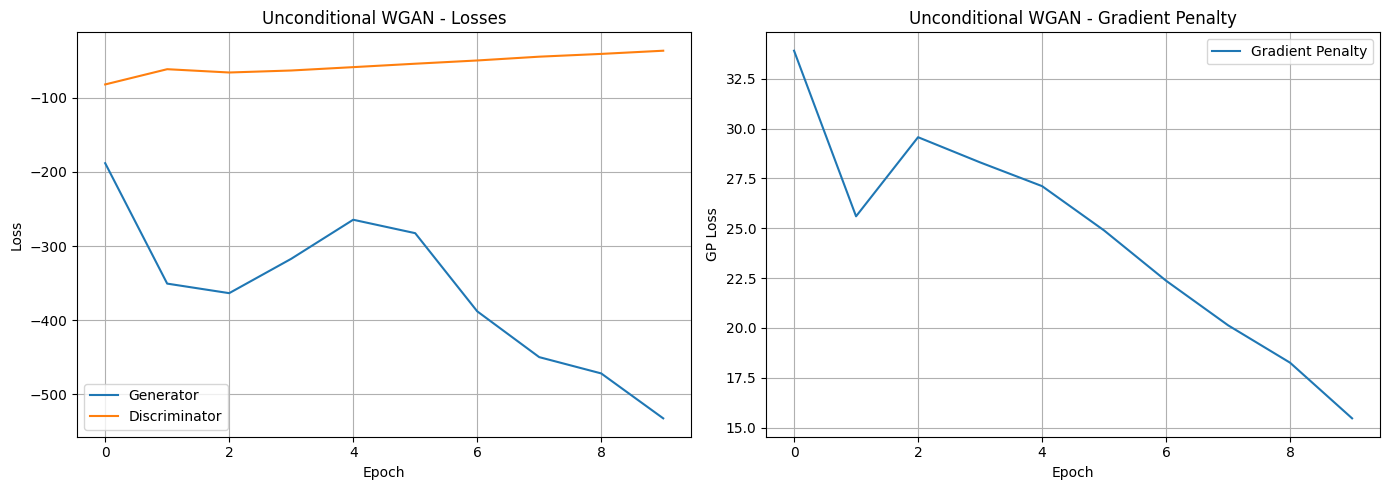

\n==================================================
Training and evaluation completed!


In [142]:
wgan_gen = WGANGenerator(latent_dim=config['latent_dim']).to(config['device'])
wgan_path = os.path.join('lab4', 'wgan_gen_unconditional.pth')
if os.path.exists(wgan_path):
    wgan_gen.load_state_dict(torch.load(wgan_path))
cwgan_gen = ConditionalWGANGenerator(latent_dim=config['latent_dim'], num_attrs=config['num_attrs']).to(config['device'])
cwgan_path = os.path.join('lab4', 'cwgan_gen_conditional.pth')
if os.path.exists(cwgan_path):
    cwgan_gen.load_state_dict(torch.load(cwgan_path))

# Calculate metrics if we have trained models
if dataset is not None:
    print("\\nCalculating metrics...")

    # Extract features using Inception (use metrics device)
    print(f"Using device {config['metrics_device']} for metrics calculation")

    # Extract features directly without storing all samples
    real_features_list = []
    fake_features_list = []

    wgan_gen.eval()
    feature_extractor = InceptionFeatureExtractor(
        device=config['metrics_device'],
        batch_size=config['metrics_batch_size']
    )

    total_samples = 0
    with torch.no_grad():
        for images, attrs, _ in tqdm(val_loader, desc='Extracting features'):
            # Stop if we have enough samples
            if total_samples >= config['max_fid_samples']:
                break

            # Move to training device for generation
            images = images.to(config['device'])

            # Extract real features
            real_features = feature_extractor.extract_features(images.cpu())
            real_features_list.append(real_features)

            # Generate and extract fake features
            z_wgan = torch.randn(images.shape[0], config['latent_dim'], device=config['device'])
            fake_wgan = wgan_gen(z_wgan)
            fake_features = feature_extractor.extract_features(fake_wgan.cpu())
            fake_features_list.append(fake_features)

            total_samples += images.shape[0]

            # Clear cache
            if config['device'].startswith('cuda'):
                torch.cuda.empty_cache()
            if config['metrics_device'].startswith('cuda') and config['metrics_device'] != config['device']:
                torch.cuda.empty_cache()

    # Concatenate features
    real_features = np.concatenate(real_features_list, axis=0)
    wgan_features = np.concatenate(fake_features_list, axis=0)

    print(f"Extracted features from {len(real_features)} samples for FID calculation")

    # Calculate FID
    print("Calculating FID scores...")
    fid_wgan = calculate_fid(real_features, wgan_features)

    print(f"\\n✓ FID Scores:")
    print(f"  WGAN: {fid_wgan:.4f}")
    print(f"  (Lower is better, typically 1-100 for quality images)")

# Plot training curves
if dataset is not None:
    print("\\nPlotting training curves...")
    histories = {
        'wgan': wgan_history if 'wgan_history' in locals() else {},
    }
    plot_training_curves(histories)

print("\\n" + "="*50)
print("Training and evaluation completed!")
print("="*50)

\nGenerating sample images...


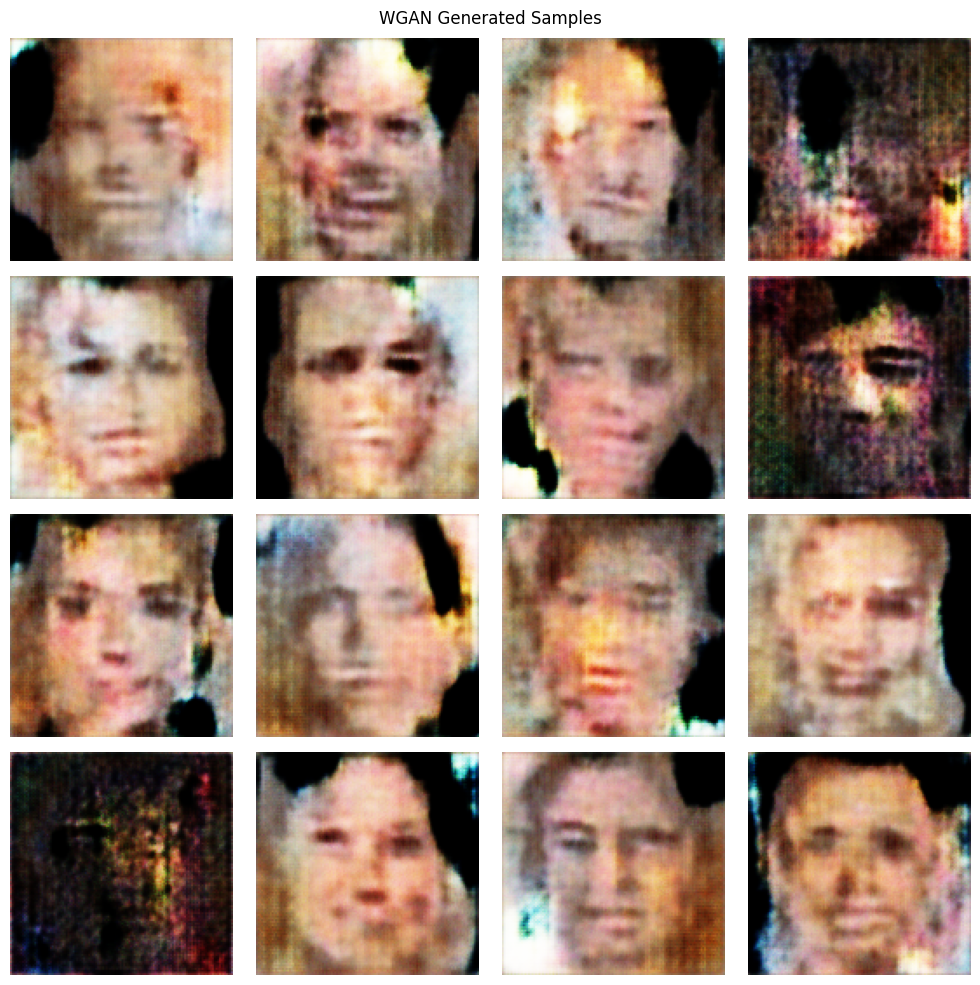

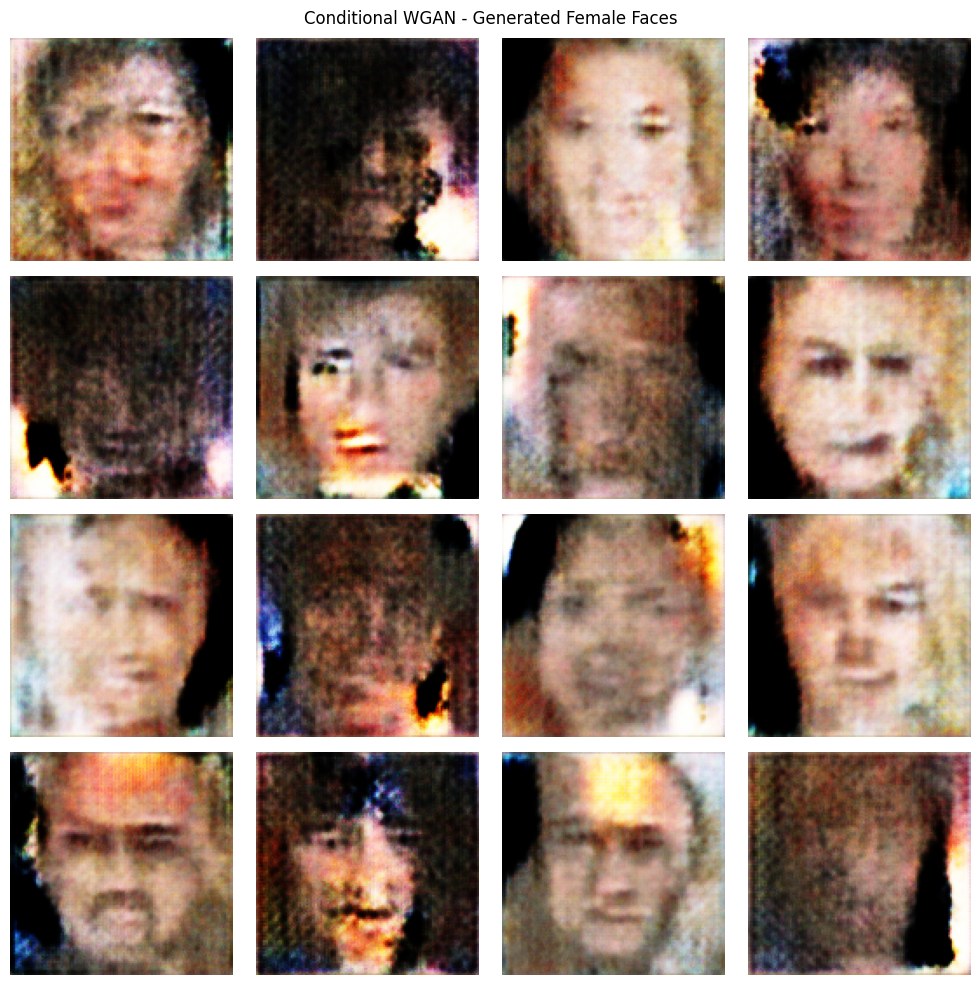

In [143]:
if dataset is not None:
    print("\\nGenerating sample images...")

    # WGAN samples
    wgan_samples = generate_samples(wgan_gen, num_samples=16, device=config['device'], conditional=False)
    fig = visualize_samples(wgan_samples, "WGAN Generated Samples")
    plt.savefig('lab4/wgan_samples.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Conditional WGAN samples
    if 'cwgan_gen' in locals():
        # Generate samples with specific attributes (e.g., female faces)
        female_attrs = torch.zeros(16, config['num_attrs'], dtype=torch.float32)
        female_attrs[:, 20] = 1  # Male attribute index (typically around 20)
        cwgan_samples = generate_samples(cwgan_gen, num_samples=16, device=config['device'],  conditional=True, attrs=female_attrs.to(config['device']))
        fig = visualize_samples(cwgan_samples, "Conditional WGAN - Generated Female Faces")
        plt.savefig('lab4/cwgan_female_samples.png', dpi=100, bbox_inches='tight')
        plt.show()